In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_mood_smartphone.csv")

In [3]:
df

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [4]:
df['time'] = pd.to_datetime(df['time'])

In [5]:
df['date'] = df['time'].dt.date

In [6]:
df_grouped = (
    df.groupby(['id', 'date', 'variable'])['value'].mean().reset_index()
)

In [7]:
df_grouped

,id,date,variable,value
0,AS14.01,2014-02-17,call,1.000000
1,AS14.01,2014-02-18,call,1.000000
2,AS14.01,2014-02-19,call,1.000000
3,AS14.01,2014-02-19,sms,1.000000
4,AS14.01,2014-02-20,call,1.000000
...,...,...,...,...
15517,AS14.33,2014-05-30,mood,6.800000
15518,AS14.33,2014-05-30,screen,86.342245
15519,AS14.33,2014-05-31,circumplex.arousal,-2.000000
15520,AS14.33,2014-05-31,circumplex.valence,1.000000


In [8]:
df_final = df_grouped.pivot_table(
    index=['id', 'date'],
    columns='variable',
    values='value'
).reset_index()

In [9]:
df_final

variable,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1968,AS14.33,2014-05-27,0.012704,8.545776,59.382943,62.347000,NaN,NaN,NaN,17.835750,...,NaN,NaN,18.724333,NaN,1.0,-0.600000,0.4,6.2,113.607750,1.0
1969,AS14.33,2014-05-28,0.103301,9.590398,37.238750,43.907571,NaN,NaN,44.738625,27.891895,...,NaN,NaN,5.111000,NaN,1.0,0.000000,1.2,8.2,113.657683,1.0
1970,AS14.33,2014-05-29,0.169354,6.452161,54.388125,68.369000,NaN,NaN,NaN,9.734000,...,0.939000,NaN,1.599500,NaN,1.0,-1.333333,1.0,7.0,118.978033,1.0
1971,AS14.33,2014-05-30,0.192901,14.776845,46.412278,37.174286,NaN,NaN,NaN,10.522000,...,37.594571,2.690667,15.521667,NaN,1.0,-0.800000,-0.4,6.8,86.342245,NaN


In [10]:
df_final['mood'].isna().sum()

705

In [11]:
df_clean = df_final.dropna(subset=['mood'])

In [12]:
df_clean

variable,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
7,AS14.01,2014-02-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,-0.250000,0.750000,6.250000,NaN,1.0
8,AS14.01,2014-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.333333,6.333333,NaN,NaN
26,AS14.01,2014-03-21,0.134050,14.269173,55.095526,53.024000,6.193000,NaN,57.402000,29.968875,...,70.418846,NaN,23.029000,NaN,1.0,0.200000,0.200000,6.200000,153.665872,NaN
27,AS14.01,2014-03-22,0.236880,7.781160,51.697062,46.662000,7.025333,NaN,NaN,14.020429,...,37.305000,NaN,39.207000,NaN,1.0,0.600000,0.500000,6.400000,47.613651,1.0
28,AS14.01,2014-03-23,0.142741,12.134396,53.442031,31.448667,10.850750,NaN,NaN,12.137167,...,NaN,NaN,30.086000,30.386,NaN,0.200000,0.800000,6.800000,67.067644,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1968,AS14.33,2014-05-27,0.012704,8.545776,59.382943,62.347000,NaN,NaN,NaN,17.835750,...,NaN,NaN,18.724333,NaN,1.0,-0.600000,0.400000,6.200000,113.607750,1.0
1969,AS14.33,2014-05-28,0.103301,9.590398,37.238750,43.907571,NaN,NaN,44.738625,27.891895,...,NaN,NaN,5.111000,NaN,1.0,0.000000,1.200000,8.200000,113.657683,1.0
1970,AS14.33,2014-05-29,0.169354,6.452161,54.388125,68.369000,NaN,NaN,NaN,9.734000,...,0.939000,NaN,1.599500,NaN,1.0,-1.333333,1.000000,7.000000,118.978033,1.0
1971,AS14.33,2014-05-30,0.192901,14.776845,46.412278,37.174286,NaN,NaN,NaN,10.522000,...,37.594571,2.690667,15.521667,NaN,1.0,-0.800000,-0.400000,6.800000,86.342245,NaN


In [13]:
df_clean.to_csv("processed_data.csv", index=False)

# Dataset Properties

In [14]:
len(df_clean)

1268

In [15]:
len(df_clean['id'].unique())

27

In [16]:
len(df_clean.columns)

21

In [17]:
df_clean.astype({"id": "string", "date": "datetime64[ns]", "sms":"Int8", "call":"Int8"}).dtypes

variable
id                      string[python]
date                    datetime64[ns]
activity                       float64
appCat.builtin                 float64
appCat.communication           float64
appCat.entertainment           float64
appCat.finance                 float64
appCat.game                    float64
appCat.office                  float64
appCat.other                   float64
appCat.social                  float64
appCat.travel                  float64
appCat.unknown                 float64
appCat.utilities               float64
appCat.weather                 float64
call                              Int8
circumplex.arousal             float64
circumplex.valence             float64
mood                           float64
screen                         float64
sms                               Int8
dtype: object

### Time Span of Records per Patient

In [18]:
df_dates = df_clean.groupby('id')['date'].agg(
    start_date='min',
    end_date='max'
).reset_index()

df_dates['start_date'] = pd.to_datetime(df_dates['start_date'])
df_dates['end_date'] = pd.to_datetime(df_dates['end_date'])
df_dates['duration_days'] = (df_dates['end_date'] - df_dates['start_date']).dt.days + 1

In [19]:
df_dates

,id,start_date,end_date,duration_days
0,AS14.01,2014-02-26,2014-05-04,68
1,AS14.02,2014-03-16,2014-04-25,41
2,AS14.03,2014-03-21,2014-05-07,48
3,AS14.05,2014-03-14,2014-05-05,53
4,AS14.06,2014-03-24,2014-05-08,46
5,AS14.07,2014-03-19,2014-05-05,48
6,AS14.08,2014-03-05,2014-05-05,62
7,AS14.09,2014-03-21,2014-05-05,46
8,AS14.12,2014-03-15,2014-05-05,52
9,AS14.13,2014-03-13,2014-05-04,53


In [20]:
print(f"Min number of days is {df_dates['duration_days'].min()} and Max number of days are {df_dates['duration_days'].max()}")

Min number of days is 31 and Max number of days are 69


# Variable Analysis

### Distribution of Mood values 

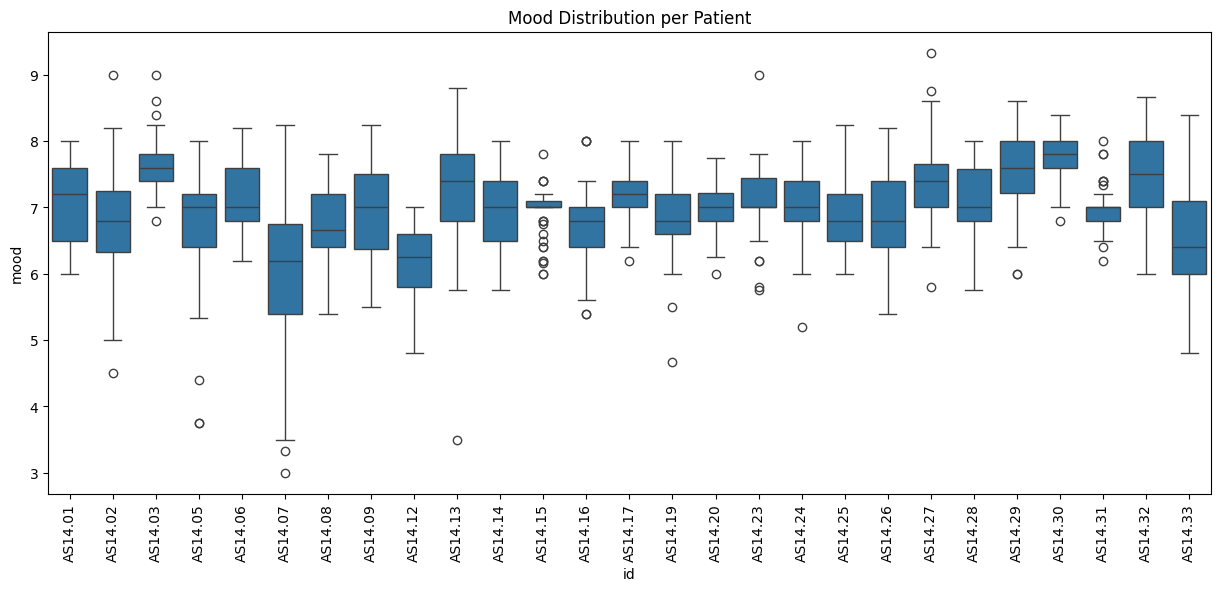

In [21]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='id', y='mood', data=df_clean)
plt.title("Mood Distribution per Patient")
plt.xticks(rotation= 90)
plt.show()

### Comparing sum of all apps with screen column

In [22]:
temp = df_clean[['appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'sms', 'screen']]

In [23]:
cols = [
    'appCat.builtin', 'appCat.communication', 'appCat.entertainment',
    'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other',
    'appCat.social', 'appCat.travel', 'appCat.unknown',
    'appCat.utilities', 'appCat.weather'
]

def sum_check(df):
    df['sum'] = df[cols].sum(axis=1)
    df['value'] = df['sum'] == df['screen']
    
    return df

In [24]:
temp = sum_check(temp)

/var/folders/yq/hljbnxms7_j_rsl4pbply_280000gn/T/ipykernel_13745/3833835401.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sum'] = df[cols].sum(axis=1)
/var/folders/yq/hljbnxms7_j_rsl4pbply_280000gn/T/ipykernel_13745/3833835401.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['value'] = df['sum'] == df['screen']


In [25]:
temp = temp.dropna(subset=['screen'])

In [26]:
temp

variable,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,sms,screen,sum,value
26,14.269173,55.095526,53.024000,6.193000,NaN,57.402000,29.968875,75.141667,70.418846,NaN,23.029000,NaN,1.0,NaN,153.665872,384.542087,False
27,7.781160,51.697062,46.662000,7.025333,NaN,NaN,14.020429,36.636000,37.305000,NaN,39.207000,NaN,1.0,1.0,47.613651,240.333984,False
28,12.134396,53.442031,31.448667,10.850750,NaN,NaN,12.137167,50.046611,NaN,NaN,30.086000,30.386,NaN,NaN,67.067644,230.531621,False
29,4.982506,47.541687,122.121375,5.684333,NaN,3.010000,11.093000,74.968047,83.961000,NaN,89.366000,NaN,1.0,NaN,76.772199,442.727948,False
30,10.026874,69.437507,34.103000,10.763500,NaN,NaN,29.803167,68.552536,NaN,29.402875,22.289300,NaN,NaN,1.0,169.097283,274.378758,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,7.711316,34.320472,68.876900,NaN,NaN,130.530000,16.845500,111.046204,NaN,NaN,NaN,NaN,1.0,1.0,300.399810,369.330392,False
1968,8.545776,59.382943,62.347000,NaN,NaN,NaN,17.835750,50.259100,NaN,NaN,18.724333,NaN,1.0,1.0,113.607750,217.094903,False
1969,9.590398,37.238750,43.907571,NaN,NaN,44.738625,27.891895,99.281685,NaN,NaN,5.111000,NaN,1.0,1.0,113.657683,267.759925,False
1970,6.452161,54.388125,68.369000,NaN,NaN,NaN,9.734000,198.880222,0.939000,NaN,1.599500,NaN,1.0,1.0,118.978033,340.362009,False


In [27]:
print(f"Max of Screen - {temp['screen'].max()} and min - {temp['screen'].min()}")
print(f"Max of Sum - {temp['sum'].max()} and min - {temp['sum'].min()}")

Max of Screen - 960.5031111240392 and min - 0.462000131607056
Max of Sum - 3809.9786345238094 and min - 2.31025


### Distribution of Values for each variable

In [28]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'Int8']).columns

range_df = df_clean[numeric_cols].agg(['min', 'max']).T.reset_index()
range_df.columns = ['variable', 'min', 'max']
print(range_df)

                variable         min          max
0               activity    0.000000     0.549430
1         appCat.builtin -772.768558  1399.054714
2   appCat.communication    1.095000   522.718000
3   appCat.entertainment    1.014000  1650.744000
4         appCat.finance    1.004000   149.181000
5            appCat.game    1.010000  2562.907000
6          appCat.office    0.044000  1494.864000
7           appCat.other    3.524500   722.752200
8          appCat.social    0.725000  3759.177625
9          appCat.travel    0.080000  1758.019333
10        appCat.unknown    0.111000  2239.937000
11      appCat.utilities    1.002000   363.429000
12        appCat.weather    1.007000   183.468500
13                  call    1.000000     1.000000
14    circumplex.arousal   -2.000000     2.000000
15    circumplex.valence   -1.250000     2.000000
16                  mood    3.000000     9.333333
17                screen    0.462000   960.503111
18                   sms    1.000000     1.000000


In [29]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'Int8']).columns
patient_range = df_clean.groupby('id')[numeric_cols].agg(['min', 'max']).reset_index()
patient_range

variable       id  activity           appCat.builtin               \
                        min       max            min          max   
0         AS14.01  0.014021  0.236880       4.886735   163.002043   
1         AS14.02  0.034483  0.500000       2.007000   108.851750   
2         AS14.03  0.020846  0.269142       3.217250  1399.054714   
3         AS14.05  0.002491  0.200166       6.520500   159.697857   
4         AS14.06  0.000000  0.344742       2.004500   198.741500   
5         AS14.07  0.003125  0.231307    -772.768558    42.697609   
6         AS14.08  0.002604  0.221814       2.160000   442.080091   
7         AS14.09  0.015309  0.180903       2.008000   106.462538   
8         AS14.12  0.032042  0.332577       4.599246   138.425529   
9         AS14.13  0.041411  0.468708       3.222909    49.359367   
10        AS14.14  0.000694  0.173386       7.478833  1089.834514   
11        AS14.15  0.000000  0.325952       3.322000    59.655000   
12        AS14.16  0.000000  0.354911       0.914000    30.471500   
13        AS14.17  0.008333  0.336339       3.923426   419.391783   
14        AS14.19  0.000000  0.249103       3.277466    71.262356   
15        AS14.20  0.000000  0.380208       4.078000    45.238833   
16        AS14.23  0.217996  0.549430       7.060589    48.311967   
17        AS14.24  0.002735  0.351337       6.363532   125.687450   
18        AS14.25  0.022196  0.181489       5.705009    78.550000   
19        AS14.26  0.015354  0.284123       3.106714   280.779653   
20        AS14.27  0.051389  0.361806       5.032099   171.505456   
21        AS14.28  0.000000  0.333231       3.160000    47.537026   
22        AS14.29  0.008417  0.372982       2.681667    35.317125   
23        AS14.30  0.041220  0.345104       6.223684   238.640053   
24        AS14.31  0.006158  0.480647       7.225283   287.834221   
25        AS14.32  0.029860  0.164931       7.282269    64.144000   
26        AS14.33  0.001760  0.343312       3.609625    27.761528   

variable appCat.communication             appCat.entertainment               \
                          min         max                  min          max   
0                   24.078694  143.371370            18.720000   216.053655   
1                   12.533667   59.701254             4.914500   502.235600   
2                    7.646400   89.123326             2.151774   354.550765   
3                    8.192750  100.678667             2.575882    77.913453   
4                   24.993000  151.731500             2.868453    31.014668   
5                   14.705350   98.186682            14.091000  1650.744000   
6                    7.316800  369.693500             5.516000   835.740000   
7                   13.355800   47.916727             4.890750   201.896882   
8                   17.016588  145.653286            24.214765   164.825971   
9                    1.095000  150.826692             5.725000  1232.164000   
10                   7.036000  422.559625             5.725000   245.311000   
11                   3.016000  522.718000             5.019000   414.577000   
12                   3.010000   71.993167             1.014000   557.107667   
13                  12.397300  126.766473            13.036000   952.045000   
14                   6.098000  350.434929             4.354167   546.490000   
15                   4.226000   52.738500             8.874400   123.560333   
16                  15.994000   71.662025             5.035000   349.089105   
17                  21.305311  192.232514             1.507500    36.429154   
18                  18.007333  125.895333            11.562000  1186.037000   
19                  16.833296   67.822636             9.052000   294.056000   
20                  23.750833   92.084345           162.572000   251.452000   
21                   8.015333   53.561178             5.670500   526.931000   
22                  18.864522  102.432500             7.023000  1088.969000   
23                  34.

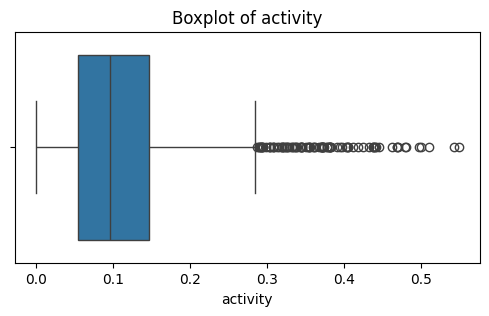

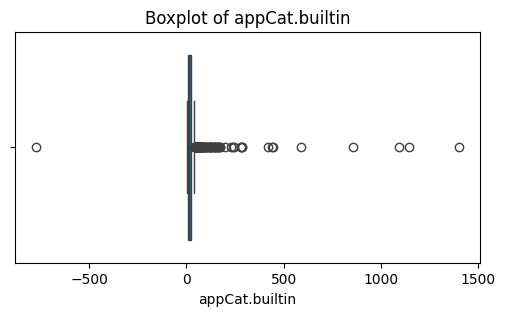

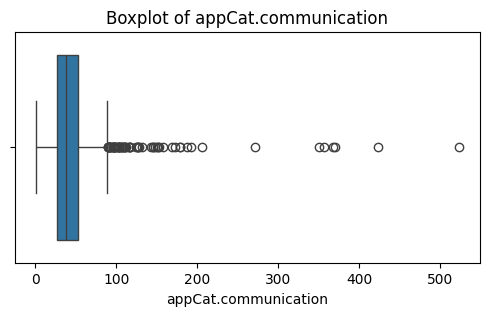

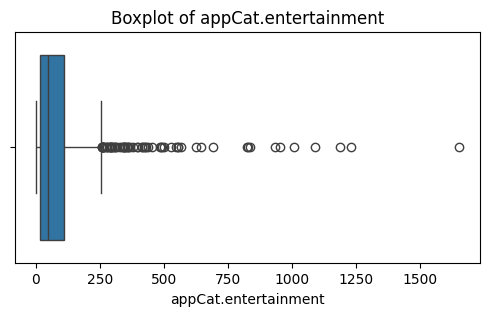

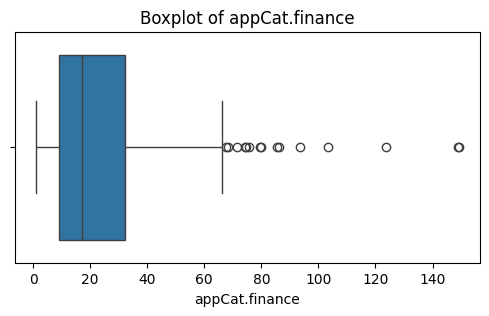

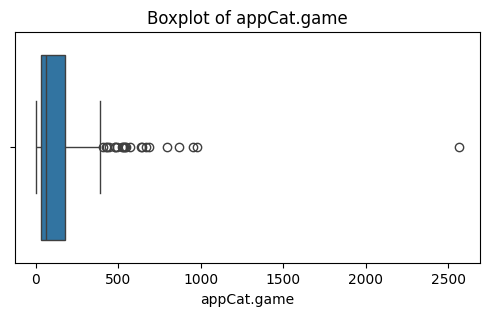

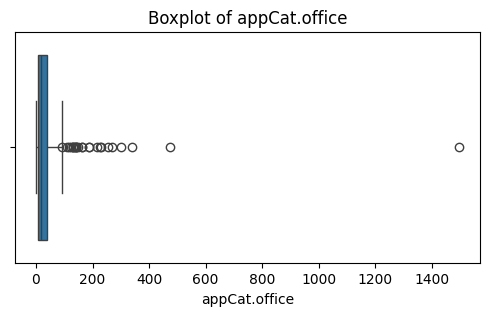

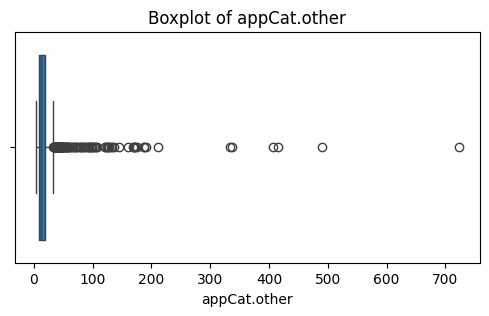

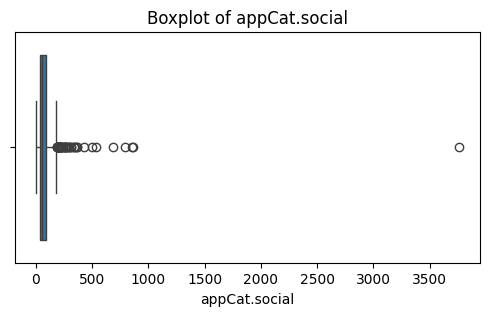

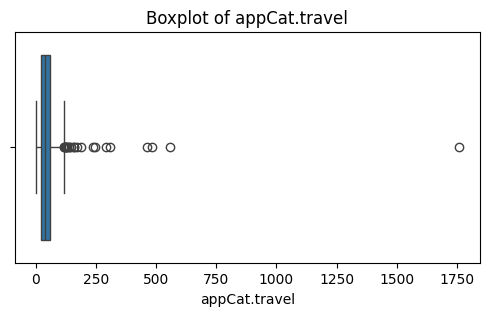

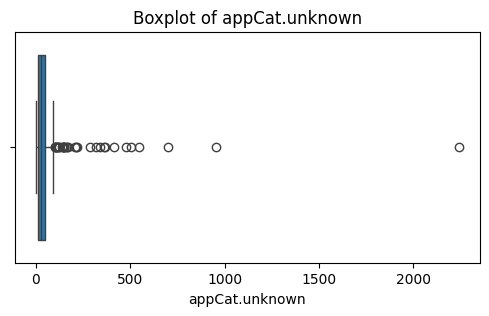

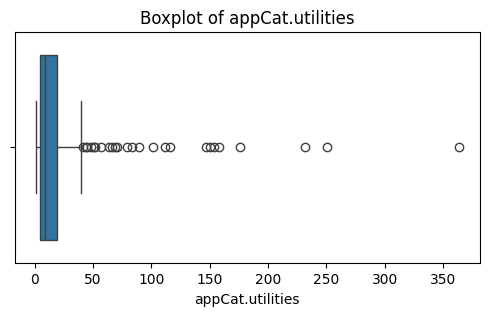

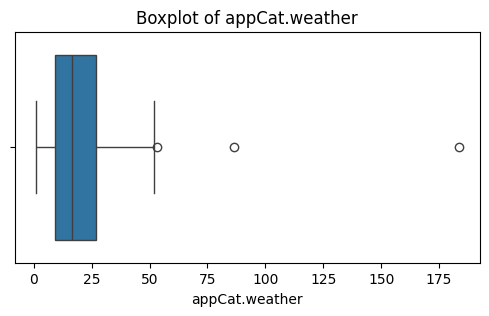

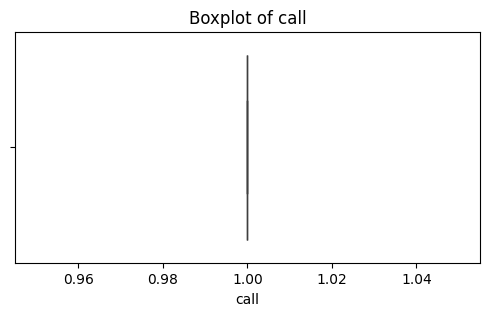

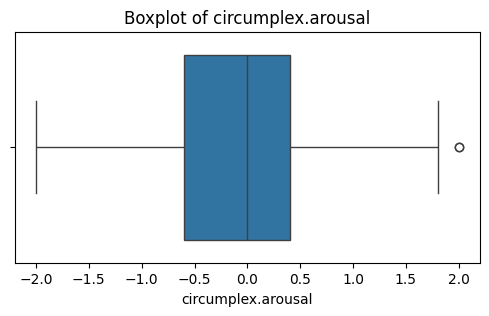

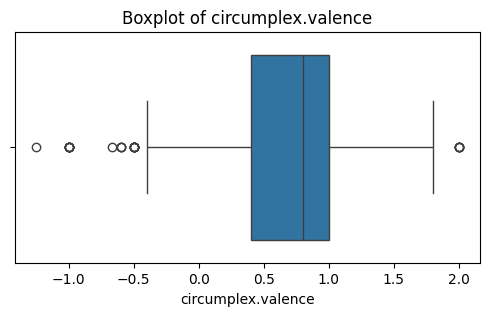

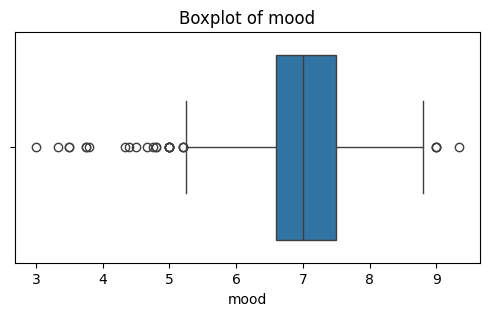

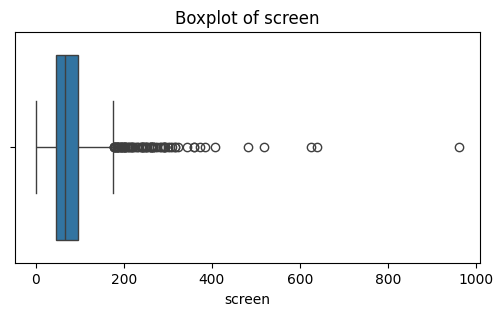

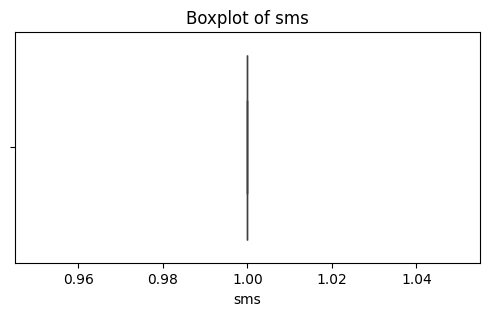

In [30]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

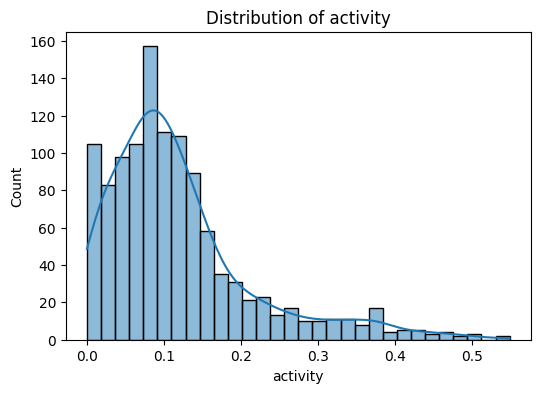

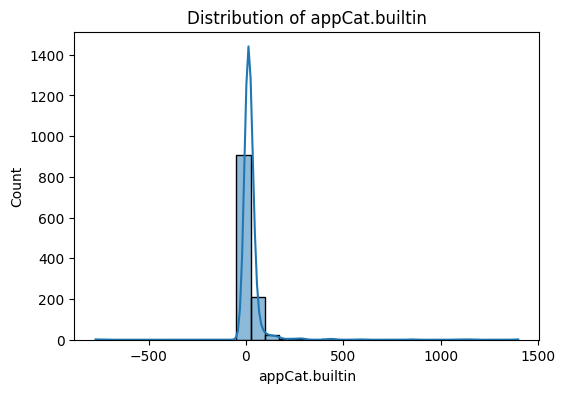

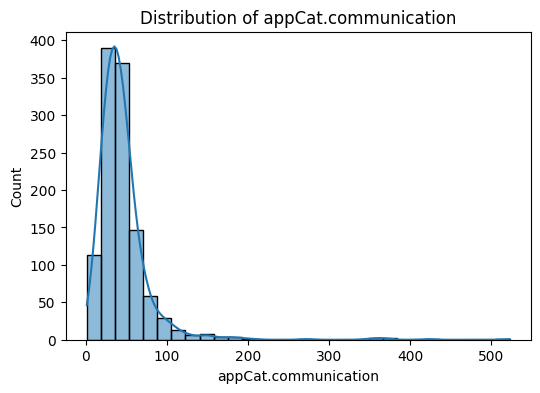

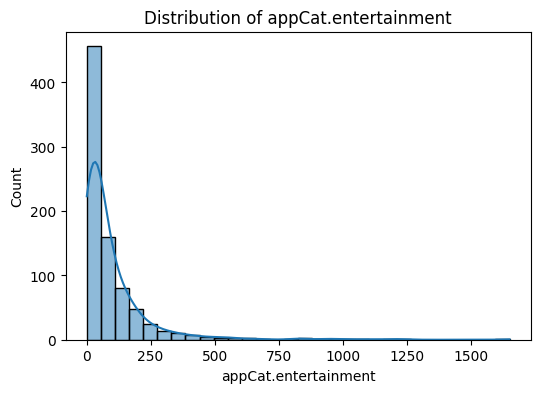

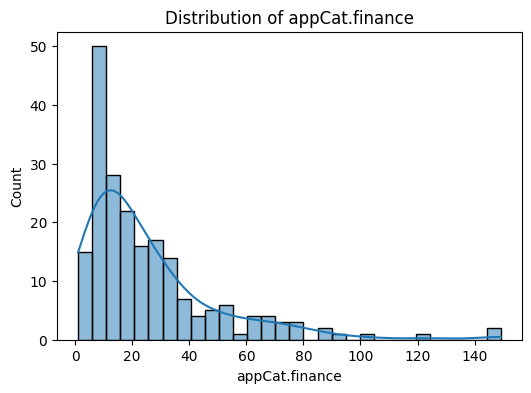

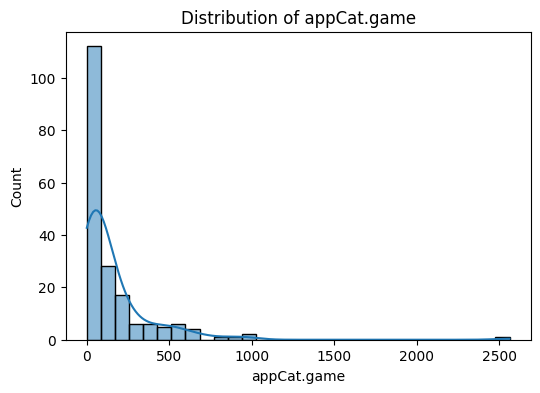

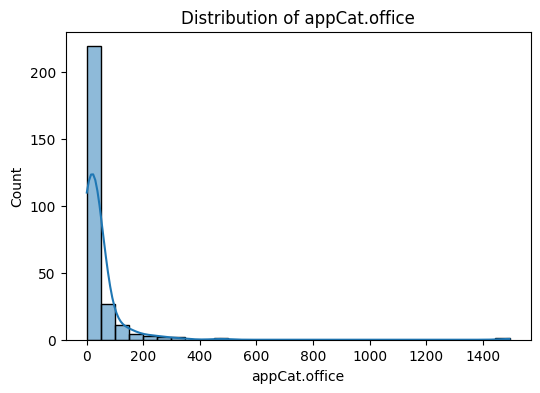

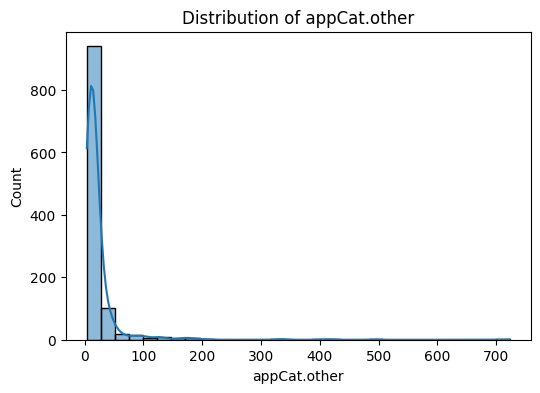

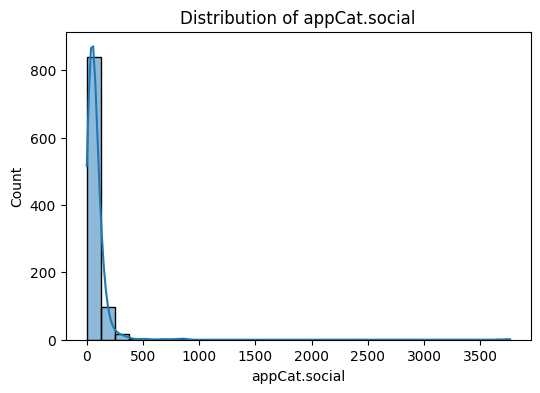

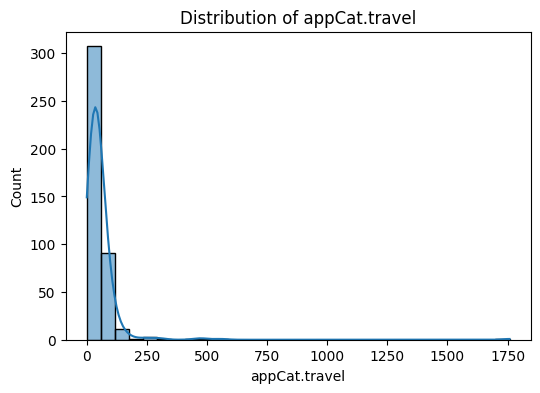

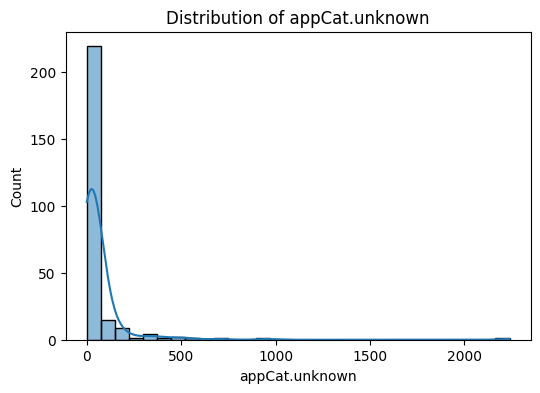

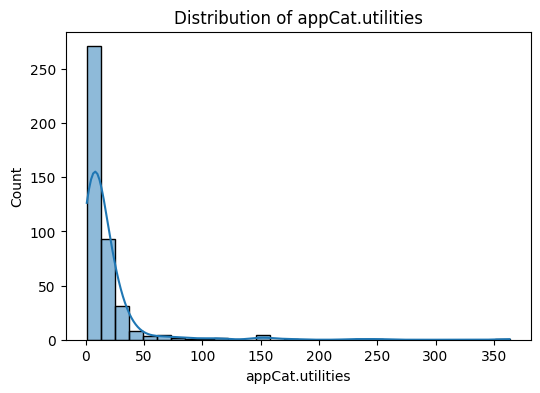

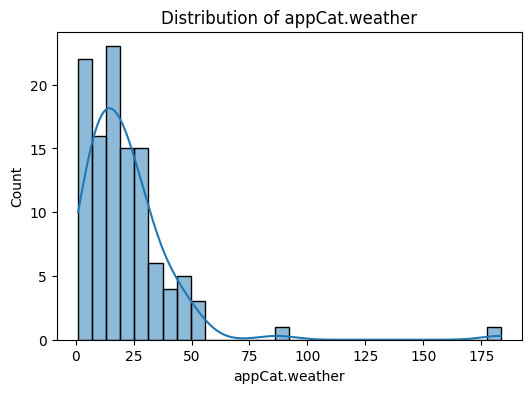

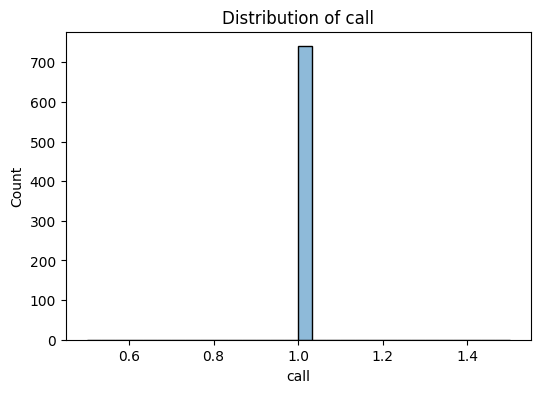

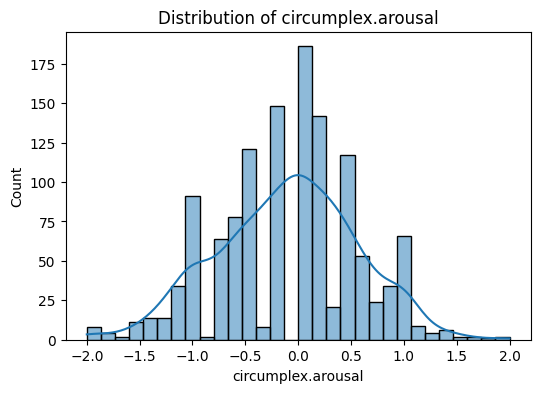

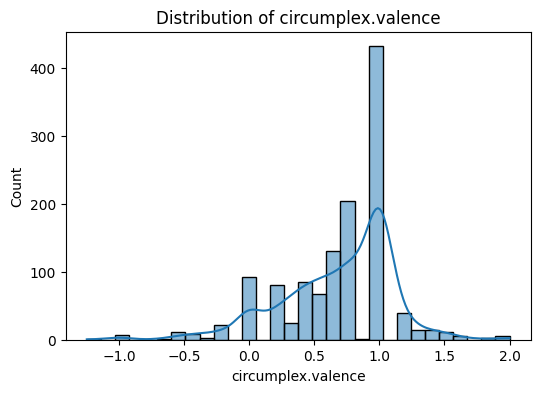

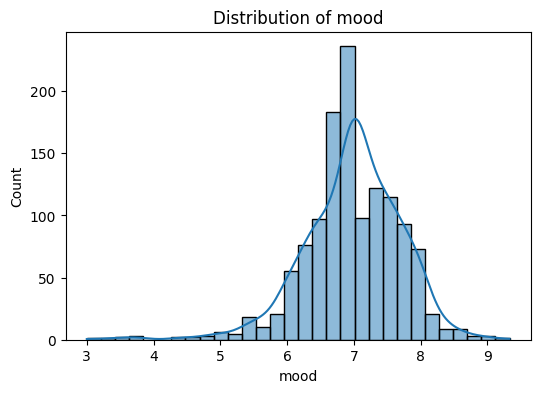

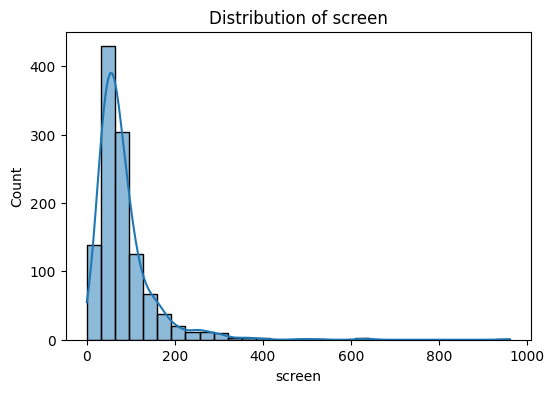

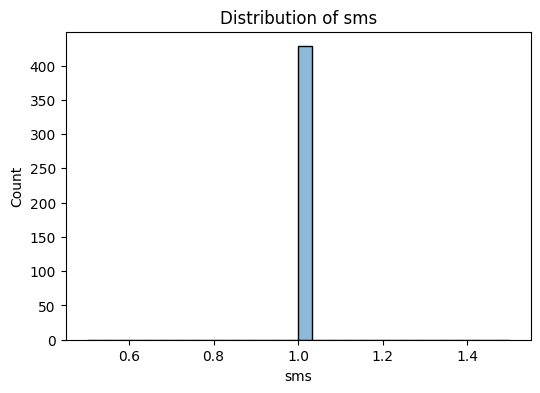

In [31]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

### Missing Values per Variable

In [32]:
missing_counts = df_clean.isna().sum().reset_index()
missing_counts.columns = ['variable', 'missing_count']
missing_counts['missing_percent'] = missing_counts['missing_count'] / len(df_clean) * 100
print(missing_counts)

                variable  missing_count  missing_percent
0                     id              0         0.000000
1                   date              0         0.000000
2               activity            118         9.305994
3         appCat.builtin            111         8.753943
4   appCat.communication            121         9.542587
5   appCat.entertainment            445        35.094637
6         appCat.finance           1062        83.753943
7            appCat.game           1079        85.094637
8          appCat.office            998        78.706625
9           appCat.other            165        13.012618
10         appCat.social            306        24.132492
11         appCat.travel            850        67.034700
12        appCat.unknown           1013        79.889590
13      appCat.utilities            844        66.561514
14        appCat.weather           1157        91.246057
15                  call            528        41.640379
16    circumplex.arousal       

<Axes: xlabel='variable', ylabel='variable'>

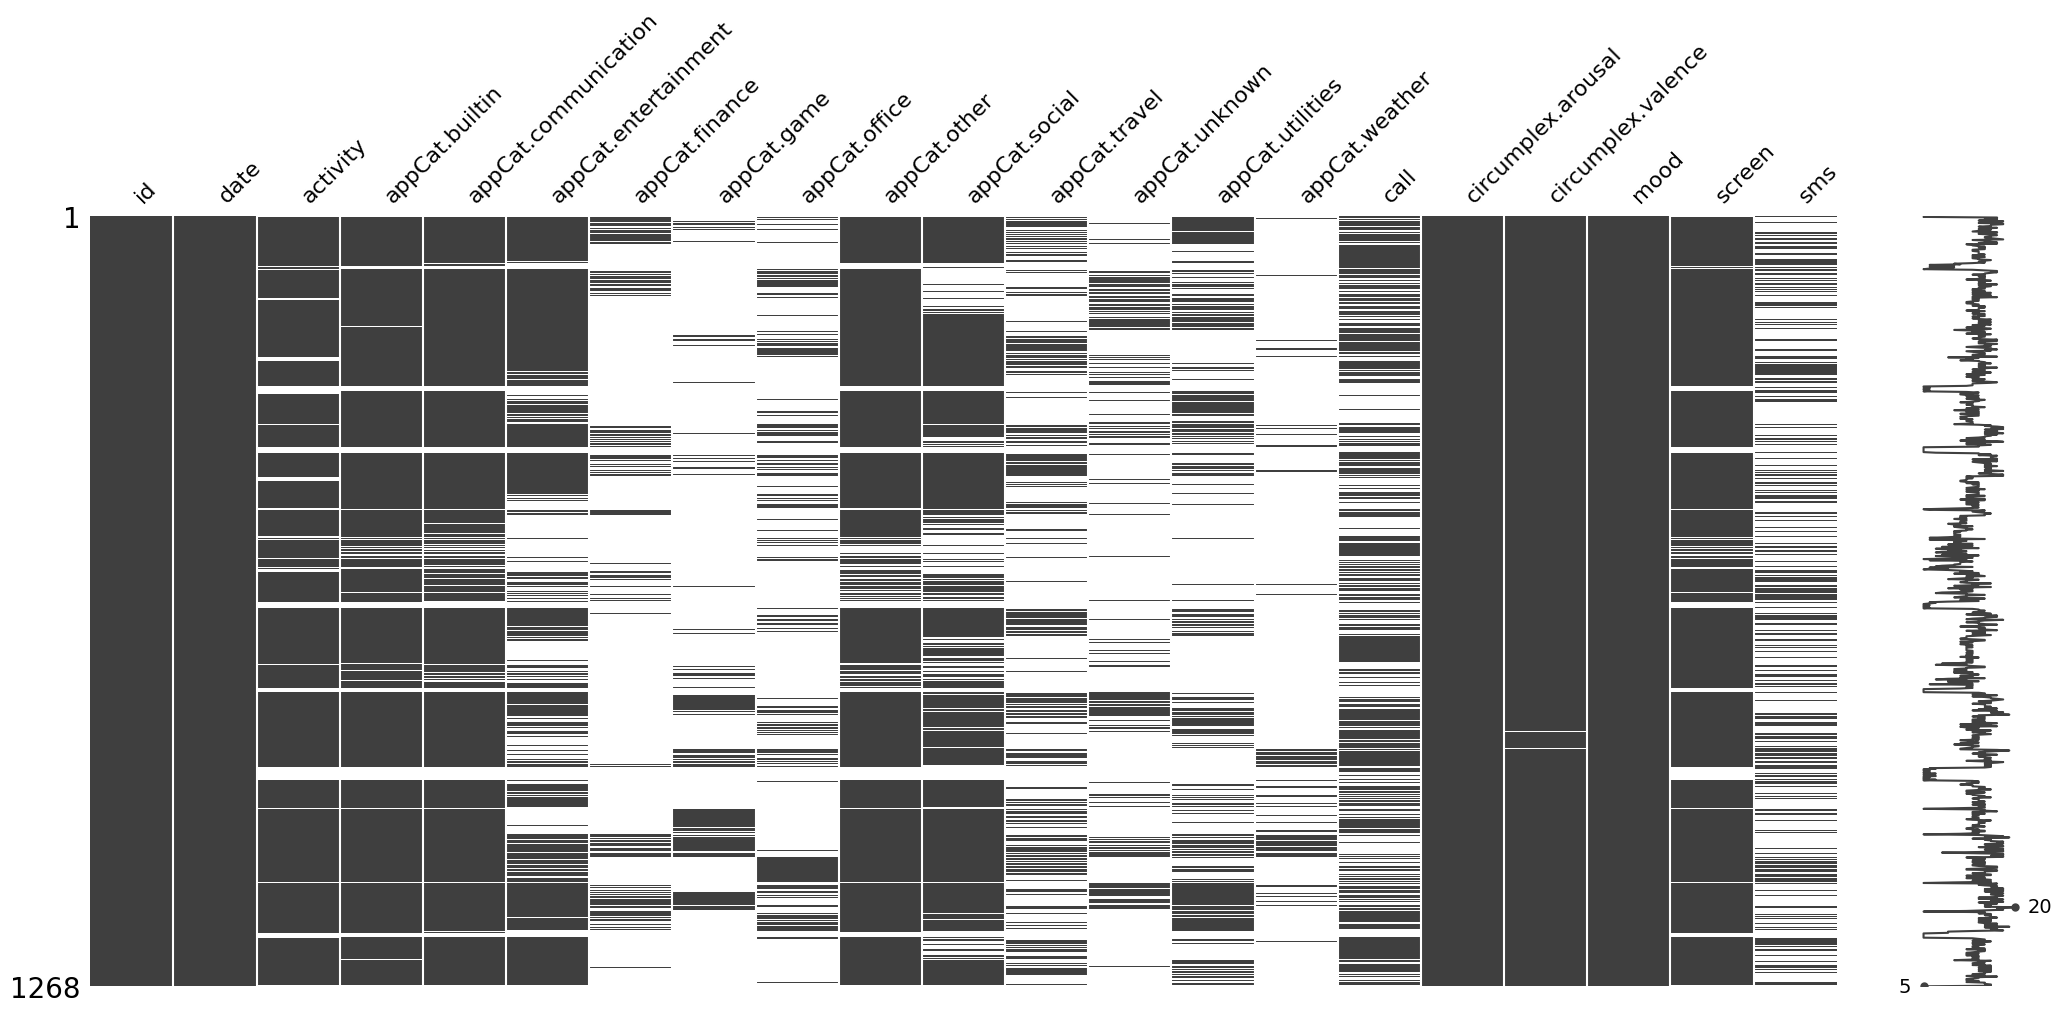

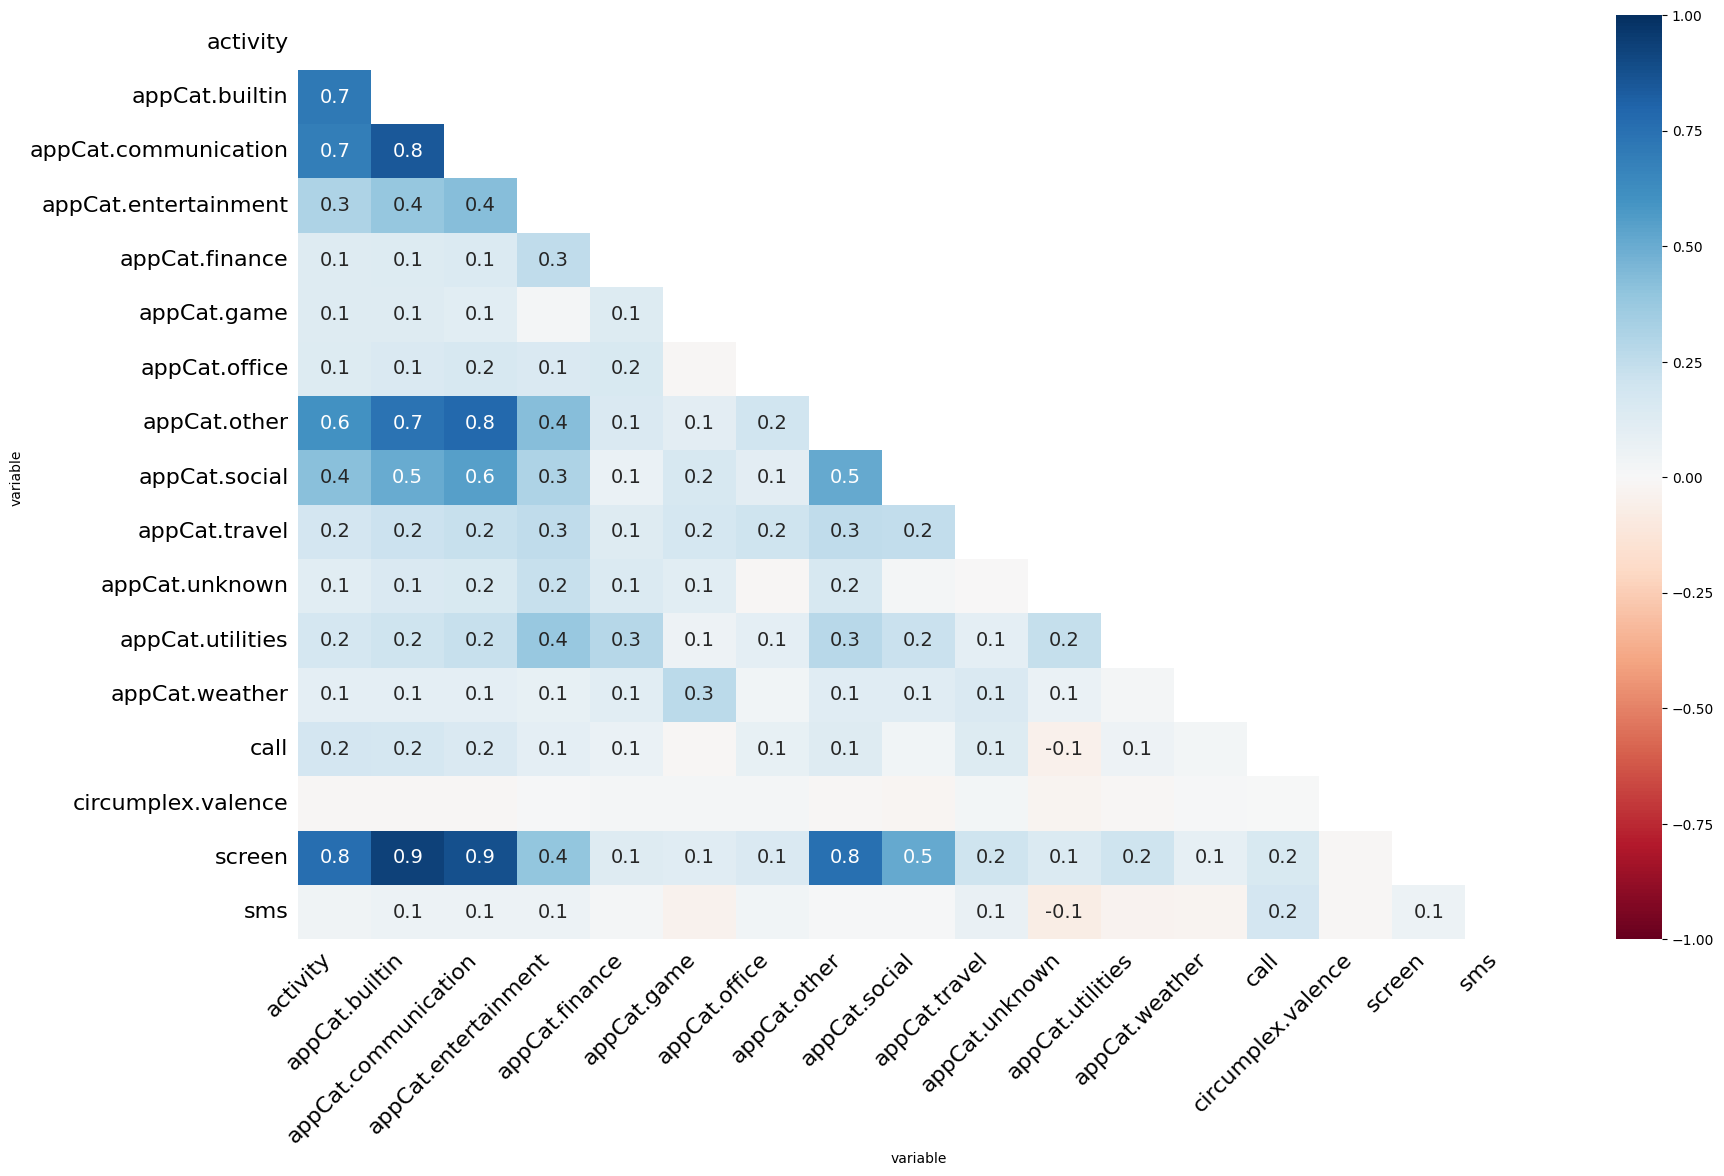

In [33]:
import missingno as msno

msno.matrix(df_clean)
msno.heatmap(df_clean)

### Number of Outliers per Variable

In [34]:
outliers = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_rows = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)]
    outliers[col] = len(outlier_rows)
    
print(outliers)

{'activity': 91, 'appCat.builtin': 110, 'appCat.communication': 67, 'appCat.entertainment': 65, 'appCat.finance': 15, 'appCat.game': 22, 'appCat.office': 25, 'appCat.other': 124, 'appCat.social': 48, 'appCat.travel': 22, 'appCat.unknown': 33, 'appCat.utilities': 25, 'appCat.weather': 3, 'call': 0, 'circumplex.arousal': 2, 'circumplex.valence': 25, 'mood': 27, 'screen': 80, 'sms': 0}


### Min and Max Gap between records per patient

In [35]:
df_sorted = df_clean.sort_values(['id', 'date'])
for pid, group in df_sorted.groupby('id'):
    diff = group['date'].diff().dt.days
    print(f"Patient {pid}: min gap = {diff.min()} days, max gap = {diff.max()} days")

Patient AS14.01: min gap = 1.0 days, max gap = 22.0 days
Patient AS14.02: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.03: min gap = 1.0 days, max gap = 2.0 days
Patient AS14.05: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.06: min gap = 1.0 days, max gap = 2.0 days
Patient AS14.07: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.08: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.09: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.12: min gap = 1.0 days, max gap = 12.0 days
Patient AS14.13: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.14: min gap = 1.0 days, max gap = 3.0 days
Patient AS14.15: min gap = 1.0 days, max gap = 2.0 days
Patient AS14.16: min gap = 1.0 days, max gap = 2.0 days
Patient AS14.17: min gap = 1.0 days, max gap = 7.0 days
Patient AS14.19: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.20: min gap = 1.0 days, max gap = 1.0 days
Patient AS14.23: min gap = 1.0 days, max gap = 2.0 days
Patient AS14.24: min gap = 1.0 days, max gap =

### Number of records per patient

In [36]:
records_per_patient = df_clean.groupby('id').size().reset_index(name='record_count')
print(records_per_patient)

         id  record_count
0   AS14.01            47
1   AS14.02            41
2   AS14.03            47
3   AS14.05            53
4   AS14.06            45
5   AS14.07            48
6   AS14.08            62
7   AS14.09            46
8   AS14.12            41
9   AS14.13            53
10  AS14.14            44
11  AS14.15            55
12  AS14.16            53
13  AS14.17            56
14  AS14.19            46
15  AS14.20            47
16  AS14.23            39
17  AS14.24            55
18  AS14.25            30
19  AS14.26            68
20  AS14.27            42
21  AS14.28            38
22  AS14.29            42
23  AS14.30            47
24  AS14.31            43
25  AS14.32            37
26  AS14.33            43


# Relationships & Patterns

### Correlation Between Variables

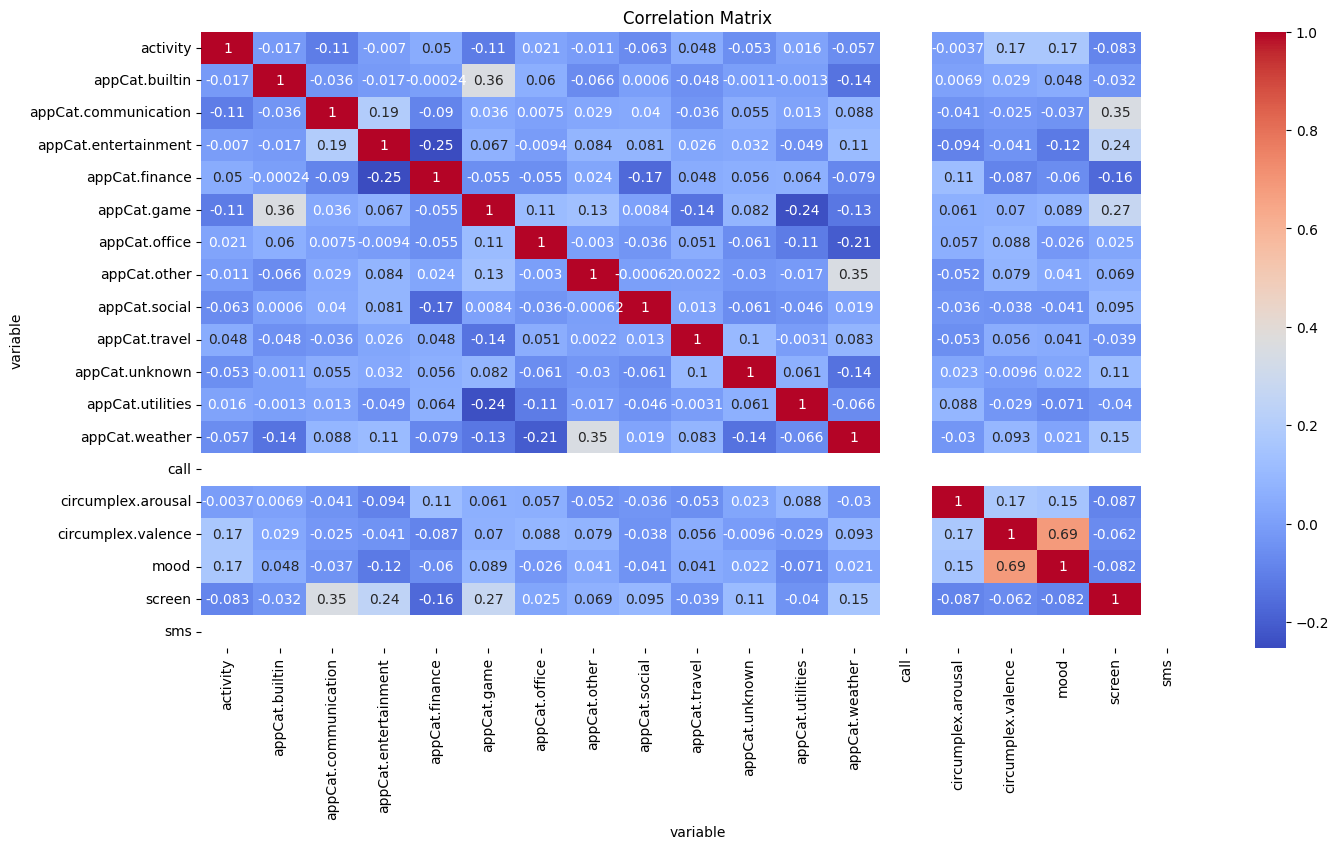

In [37]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'Int8']).columns
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Patient Specific Patterns

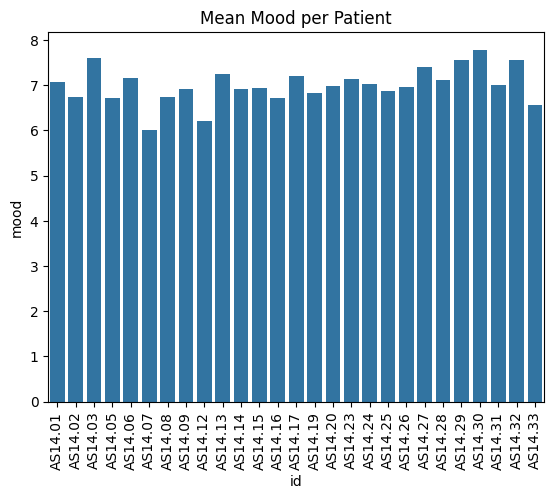

In [38]:
mean_mood = df_clean.groupby('id')['mood'].mean().reset_index()
sns.barplot(x='id', y='mood', data=mean_mood)
plt.xticks(rotation=90)
plt.title("Mean Mood per Patient")
plt.show()

### Mood vs Other Variables

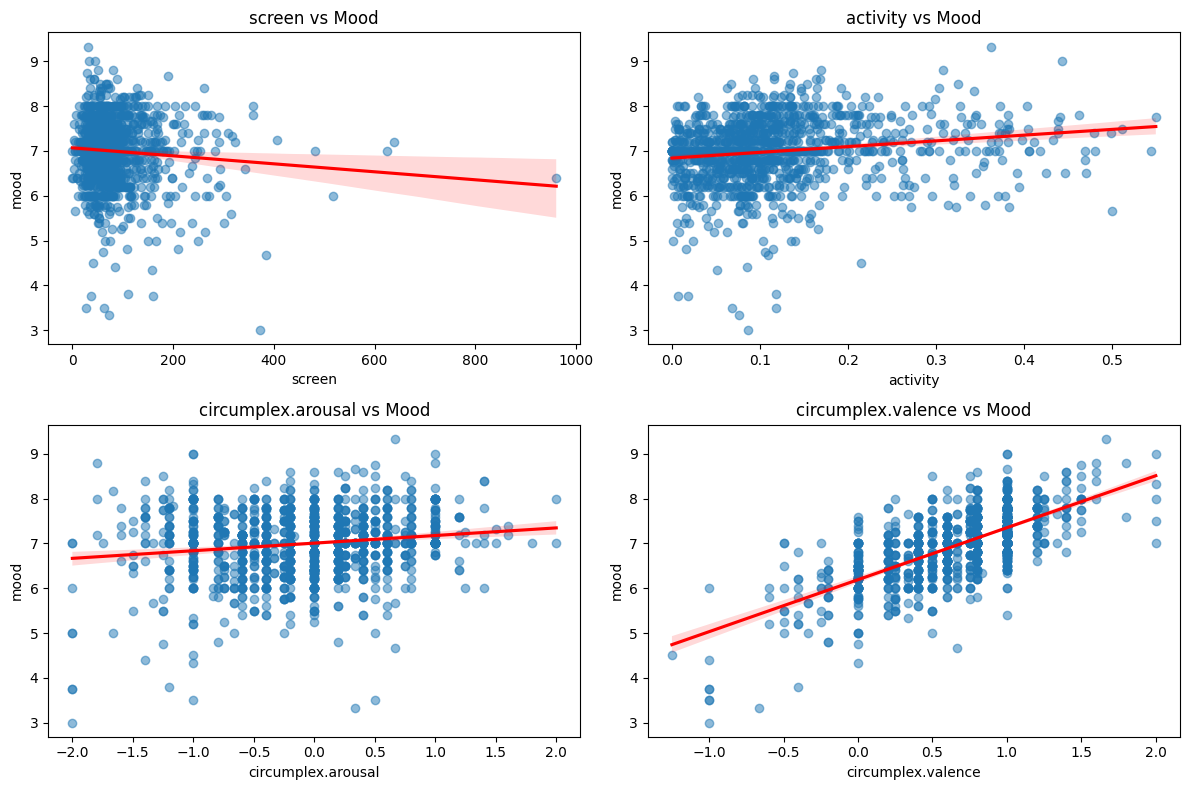

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
features = ['screen', 'activity', 'circumplex.arousal', 'circumplex.valence']
for ax, col in zip(axes.flatten(), features):
    sns.regplot(
        x=df_clean[col],
        y=df_clean['mood'],
        ax=ax,
        scatter_kws={'alpha':0.5},
        line_kws={'color':'red'}
    )
    ax.set_title(f"{col} vs Mood")

plt.tight_layout()
plt.show()

### Mood Distribution

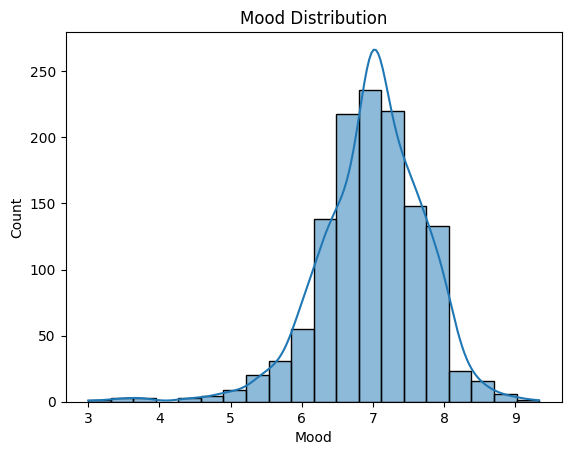

In [40]:
sns.histplot(df_clean['mood'], kde=True, bins=20)
plt.title("Mood Distribution")
plt.xlabel("Mood")
plt.show()